Am încărcat imaginea: Screenshot 2026-04-26 160920.jpg. Gata pentru Etapa 1.


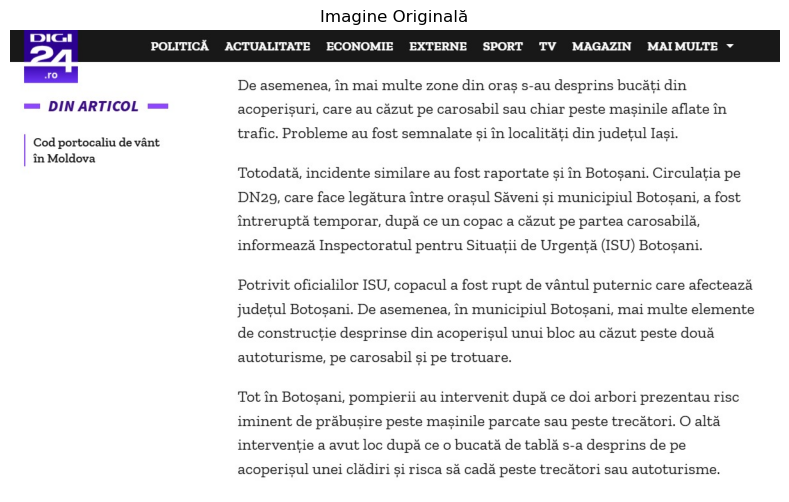

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# 1. Configurare căi
dataset_path = r"C:\Users\Bogdan\Desktop\proiect TDAV\poze MSER bune"
output_dir = "rezultate_mser"
output_dir_etape = "rezultate_mser_etape"

if not os.path.exists(output_dir): os.makedirs(output_dir)
if not os.path.exists(output_dir_etape): os.makedirs(output_dir_etape)

# 2. Alegem o imagine pentru DEMO (prima din folder)
image_files = glob.glob(os.path.join(dataset_path, '*.jpg'))
demo_path = image_files[0] 
file_name = os.path.basename(demo_path)

# Citire și pregătire
img = cv2.imread(demo_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"Am încărcat imaginea: {file_name}. Gata pentru Etapa 1.")
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("Imagine Originală")
plt.axis('off')
plt.show()

Etapa 1 Gata: Am detectat 4377 caractere potențiale.


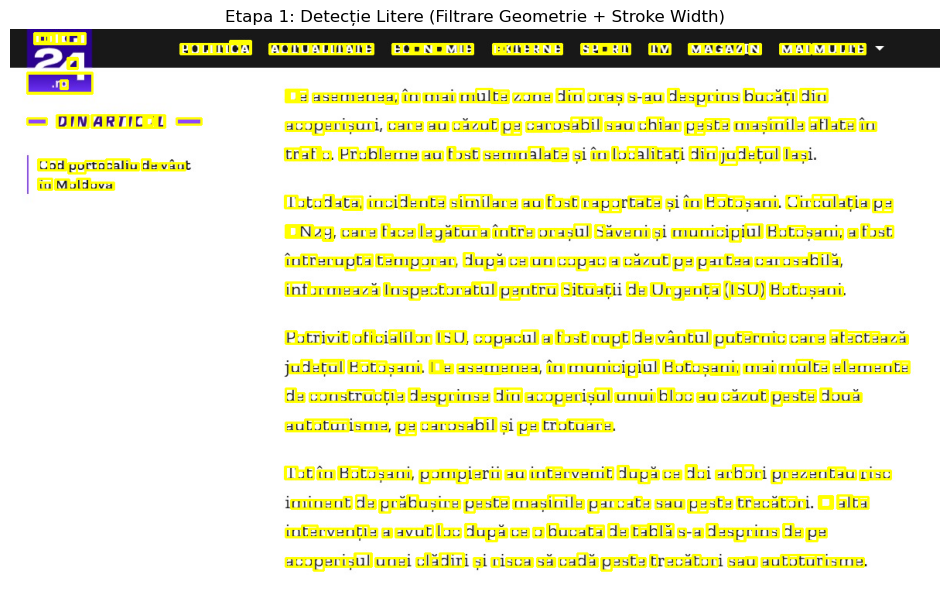

In [2]:
# Inițializare MSER
mser = cv2.MSER_create()
regions, _ = mser.detectRegions(gray)
valid_boxes = []
img_step1 = img_rgb.copy()

for region in regions:
    x, y, w, h = cv2.boundingRect(region)
    if (w*h < 80 or w*h > 10000): continue
    if (float(w)/h < 0.1 or float(w)/h > 4.0): continue

    # Filtrare Stroke Width
    mask_char = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask_char, [region - [x, y]], 255)
    mean_val, std_val = cv2.meanStdDev(cv2.distanceTransform(mask_char, cv2.DIST_L2, 3), mask=mask_char)
    if mean_val[0][0] > 0 and (std_val[0][0] / mean_val[0][0] > 0.8): continue
            
    valid_boxes.append((x, y, w, h))
    cv2.rectangle(img_step1, (x, y), (x + w, y + h), (255, 255, 0), 2)

print(f"Etapa 1 Gata: Am detectat {len(valid_boxes)} caractere potențiale.")
plt.figure(figsize=(12,8))
plt.imshow(img_step1)
plt.title("Etapa 1: Detecție Litere (Filtrare Geometrie + Stroke Width)")
plt.axis('off')
plt.show()

Etapa 2 Gata: Caracterele au fost contopite în blocuri de text.


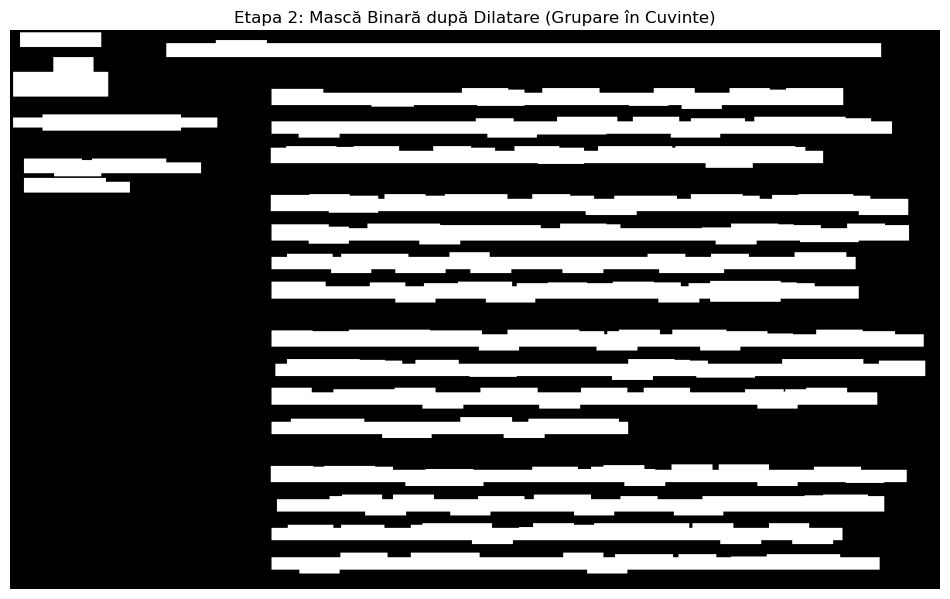

In [3]:
# Creăm masca binară
mask_words = np.zeros_like(gray)
for (x, y, w, h) in valid_boxes:
    cv2.rectangle(mask_words, (x, y), (x + w, y + h), 255, -1)

# Aplicăm dilatarea
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 3))
dilated_mask = cv2.dilate(mask_words, kernel, iterations=2)

print("Etapa 2 Gata: Caracterele au fost contopite în blocuri de text.")
plt.figure(figsize=(12,8))
plt.imshow(dilated_mask, cmap='gray')
plt.title("Etapa 2: Mască Binară după Dilatare (Grupare în Cuvinte)")
plt.axis('off')
plt.show()

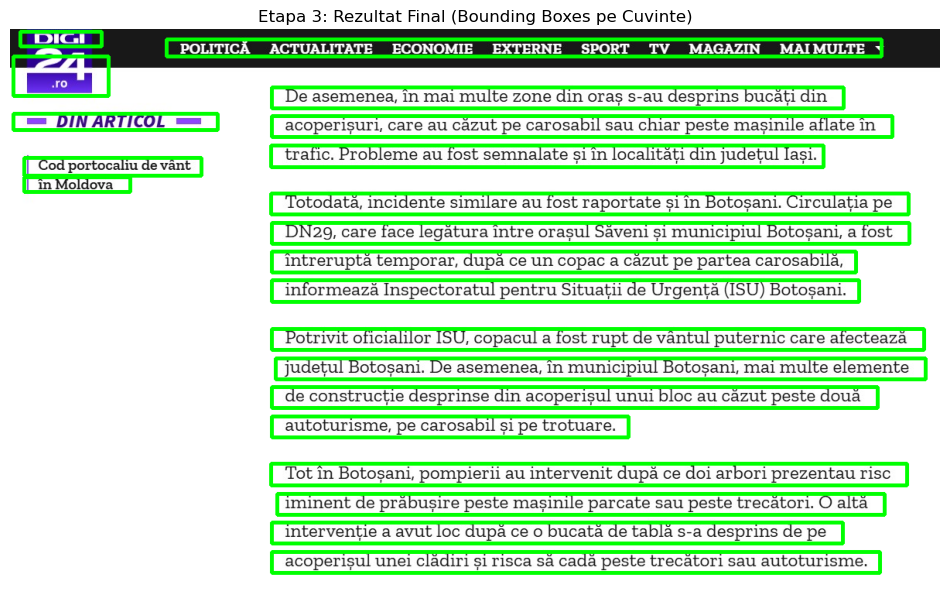


Încep procesarea automată și salvarea pentru toate imaginile...
Succes! Toate cele 10 imagini au fost procesate.
-> Verifică folderul 'rezultate_mser' pentru rezultatele finale.
-> Verifică folderul 'rezultate_mser_etape' pentru explicațiile pas-cu-pas.


In [4]:
img_step3 = img_rgb.copy()
contours, _ = cv2.findContours(dilated_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Desenăm dreptunghiurile verzi finale pe cuvinte
for contour in contours:
    if cv2.contourArea(contour) > 100:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(img_step3, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.figure(figsize=(12,8))
plt.imshow(img_step3)
plt.title("Etapa 3: Rezultat Final (Bounding Boxes pe Cuvinte)")
plt.axis('off')
plt.show()


# PROCESARE BATCH PENTRU TOATE IMAGINILE

print("\nÎncep procesarea automată și salvarea pentru toate imaginile...")

def process_and_save_mser(img_path, out_dir, out_dir_etape):
    # Citire
    img = cv2.imread(img_path)
    if img is None: return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    img_chars = img_rgb.copy()
    output_img = img_rgb.copy()

    # MSER & Filtrare
    mser = cv2.MSER_create()
    regions, _ = mser.detectRegions(gray)
    valid_boxes = []

    for region in regions:
        x, y, w, h = cv2.boundingRect(region)
        area = w * h
        if area < 80 or area > 10000: continue
        aspect_ratio = float(w) / h
        if aspect_ratio < 0.1 or aspect_ratio > 4.0: continue

        mask_char = np.zeros((h, w), dtype=np.uint8)
        local_region = region - [x, y]
        cv2.fillPoly(mask_char, [local_region], 255)
        dist_transform = cv2.distanceTransform(mask_char, cv2.DIST_L2, 3)
        mean_val, std_val = cv2.meanStdDev(dist_transform, mask=mask_char)
        
        if mean_val[0][0] > 0:
            if (std_val[0][0] / mean_val[0][0]) > 0.8: continue
                
        valid_boxes.append((x, y, w, h))
        cv2.rectangle(img_chars, (x, y), (x + w, y + h), (255, 255, 0), 2)

    # Dilatare
    mask_words = np.zeros_like(gray)
    for (x, y, w, h) in valid_boxes:
        cv2.rectangle(mask_words, (x, y), (x + w, y + h), 255, -1)
        
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 3))
    dilated_mask = cv2.dilate(mask_words, kernel, iterations=2)
    
    # Contururi finale
    contours, _ = cv2.findContours(dilated_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if cv2.contourArea(contour) > 100:
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Doar poza finală
    file_name = os.path.basename(img_path)
    cv2.imwrite(os.path.join(out_dir, f"detectat_{file_name}"), cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR))
    
    # Colajul cu cei 4 pași
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(img_rgb); axes[0].set_title("1. Original", fontsize=12); axes[0].axis('off')
    axes[1].imshow(img_chars); axes[1].set_title("2. Litere (Galben)", fontsize=12); axes[1].axis('off')
    axes[2].imshow(dilated_mask, cmap='gray'); axes[2].set_title("3. Mască (Grupare)", fontsize=12); axes[2].axis('off')
    axes[3].imshow(output_img); axes[3].set_title("4. Rezultat Final", fontsize=12); axes[3].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir_etape, f"etape_{file_name}"), bbox_inches='tight')
    plt.close(fig) # Închide figura din fundal pentru a salva memorie

# Rulăm bucla peste toate pozele găsite
for img_path in image_files[:10]:
    process_and_save_mser(img_path, output_dir, output_dir_etape)

print(f"Succes! Toate cele 10 imagini au fost procesate.")
print(f"-> Verifică folderul '{output_dir}' pentru rezultatele finale.")
print(f"-> Verifică folderul '{output_dir_etape}' pentru explicațiile pas-cu-pas.")